# Comment Category Prediction

## Project Overview
To build a machine learning model to predict comment categories using text and metadata features.

**Problem Statement:**
- **Task**: Predict comment category from social media comments
- **Input**: Text comments and demographic/engagement attributes
- **Output**: Predicted category label (0, 1, 2, 3)
- **Evaluation Metric**: **F1-Macro Score** (Chosen over Accuracy due to severe class imbalance)

**Approach:**
1. Exploratory Data Analysis (EDA)
2. Data Preprocessing & Feature Engineering
3. Text Feature Extraction (TF-IDF)
4. Feature Selection & Sparse Matrix Creation
5. Baseline Model Building & Comparison
6. Hyperparameter Tuning Exploration
7. Final Model Selection & Training
8. Predictions & Submission

## 1. Import Required Libraries

We import all necessary libraries for data manipulation, model building, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import sys
import re
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, RandomizedSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight
from scipy.sparse import hstack, csr_matrix
import warnings
warnings.filterwarnings("ignore")

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 2. Load Data

Load training, test, and sample submission files.

In [2]:
# Load datasets
train_data = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_data = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_data = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

print("Dataset loaded successfully!")
print(f"Train shape: {train_data.shape}")
print(f"Test shape: {test_data.shape}")
print(f"Sample shape: {sample_data.shape}")

Dataset loaded successfully!
Train shape: (198000, 15)
Test shape: (102000, 14)
Sample shape: (102000, 2)


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Overview

In [3]:
train_data.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [4]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


### 3.2 Missing Values Analysis

Identify and visualize missing values in both train and test datasets. It's crucial to handle these before feeding data to our models.


Missing Values in Training Data:
gender      145423
race        145423
religion    145423
comment          1
dtype: int64

Missing Values in Test Data:
religion    75269
race        75269
gender      75269
dtype: int64


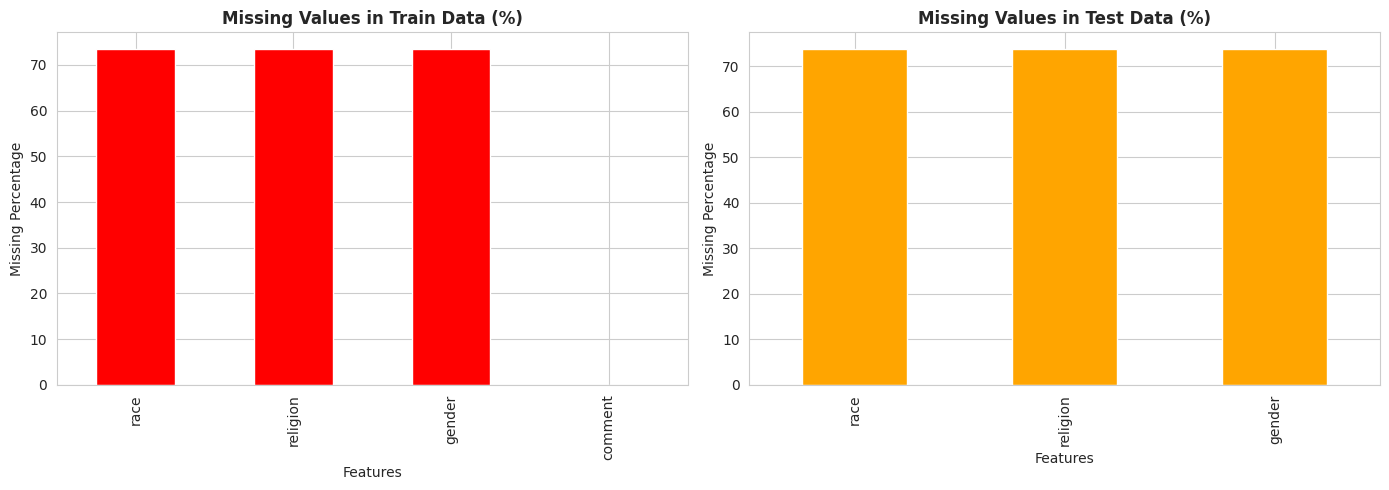

In [5]:
print("\nMissing Values in Training Data:")
missing_train = train_data.isnull().sum().sort_values(ascending=False)
missing_train = missing_train[missing_train > 0]
if len(missing_train) > 0:
    print(missing_train)
else:
    print("No missing values found!")

print("\nMissing Values in Test Data:")
missing_test = test_data.isnull().sum().sort_values(ascending=False)
missing_test = missing_test[missing_test > 0]
if len(missing_test) > 0:
    print(missing_test)
else:
    print("No missing values found!")

# Visualize missing values
missing_percentage = (train_data.isnull().sum() / len(train_data)) * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

if len(missing_percentage) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    missing_percentage.plot(kind='bar', ax=axes[0], color='red')
    axes[0].set_title('Missing Values in Train Data (%)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Features')
    axes[0].set_ylabel('Missing Percentage')
    
    missing_percentage_test = (test_data.isnull().sum() / len(test_data)) * 100
    missing_percentage_test = missing_percentage_test[missing_percentage_test > 0].sort_values(ascending=False)
    missing_percentage_test.plot(kind='bar', ax=axes[1], color='orange')
    axes[1].set_title('Missing Values in Test Data (%)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Features')
    axes[1].set_ylabel('Missing Percentage')
    
    plt.tight_layout()
    plt.show()

### 3.3 Feature Cardinality Analysis

Checking unique values per column helps us identify features that might act as noise (like IDs or highly unique timestamps).


Unique values per column:
created_date    197996
comment         197842
upvote             122
if_2                81
downvote            62
if_1                57
post_id             52
emoticon_1          36
emoticon_3          16
emoticon_2          10
religion             8
race                 6
gender               5
label                4
disability           2
dtype: int64


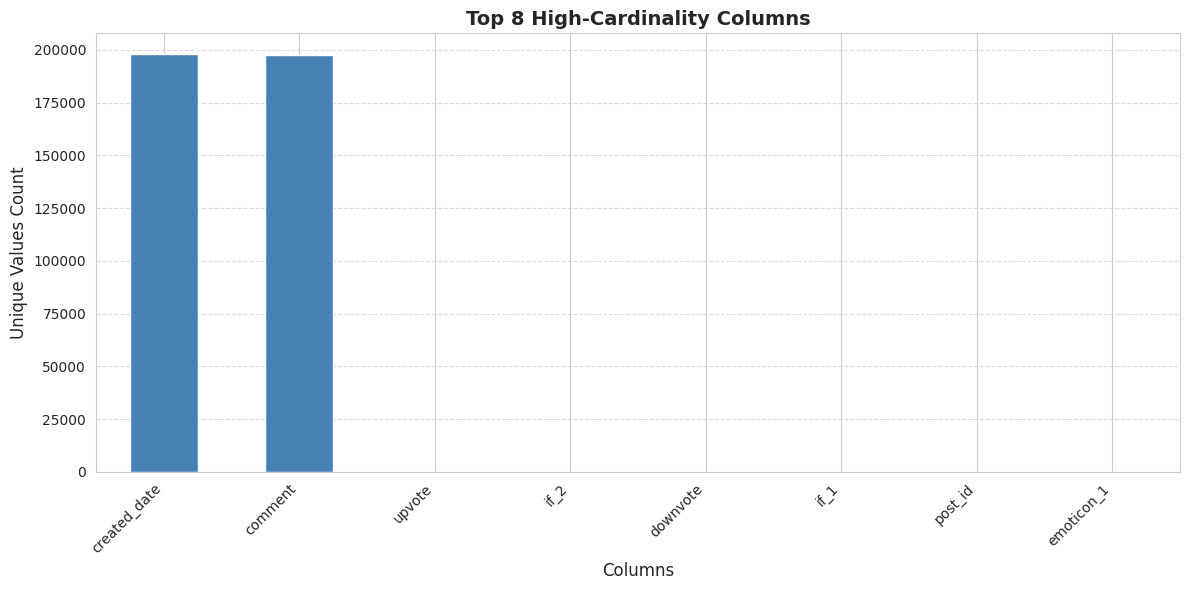

In [6]:
cardinality = train_data.nunique().sort_values(ascending=False)
print("\nUnique values per column:")
print(cardinality)

# Visualize top high-cardinality columns
top_cardinals = cardinality.head(8)
plt.figure(figsize=(12, 6))
top_cardinals.plot(kind='bar', color='steelblue')
plt.title('Top 8 High-Cardinality Columns', fontsize=14, fontweight='bold')
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Unique Values Count', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

 Note: 'created_date' has very high cardinality and 'comment' is text data.
   These will be handled in preprocessing (dropped or vectorized).

### 3.4 Numerical and Categorical Features Summary

In [7]:
print("="*80)
print("NUMERICAL FEATURES SUMMARY")
print("="*80)
numerical_features = train_data.select_dtypes(include=['int64', 'float64'])
print("\n", numerical_features.describe())

print("\n" + "="*80)
print("CATEGORICAL FEATURES SUMMARY")
print("="*80)
categorical_features = train_data.select_dtypes(include=['object'])
print(f"\nCategorical columns: {categorical_features.columns.tolist()}")
for col in categorical_features.columns:
    print(f"\n{col} (unique values: {train_data[col].nunique()}):")
    print(train_data[col].value_counts())

NUMERICAL FEATURES SUMMARY

              post_id     emoticon_1     emoticon_2     emoticon_3  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean       68.447429       0.279768       0.048338       0.121071   
std        27.948390       1.023234       0.258477       0.481013   
min        20.000000       0.000000       0.000000       0.000000   
25%        39.000000       0.000000       0.000000       0.000000   
50%        72.000000       0.000000       0.000000       0.000000   
75%        72.000000       0.000000       0.000000       0.000000   
max       129.000000      47.000000      11.000000      17.000000   

              upvote       downvote           if_1           if_2  \
count  198000.000000  198000.000000  198000.000000  198000.000000   
mean        2.607975       0.666394       1.906152       7.956212   
std         5.054763       2.044335      25.635752      14.839464   
min         0.000000       0.000000       0.000000       3.000000   
25% 

### 3.5 Target Label Distribution Analysis

**Why this is a critical step**: Understanding class distribution helps us identify imbalance. If we don't account for this, the model will just predict the majority class and look artificially "accurate."


Label Distribution (Count):
label
0    114173
1     15918
2     62440
3      5469
Name: count, dtype: int64

Label Distribution (Percentage):
  Class 0: 57.66%
  Class 1: 8.04%
  Class 2: 31.54%
  Class 3: 2.76%


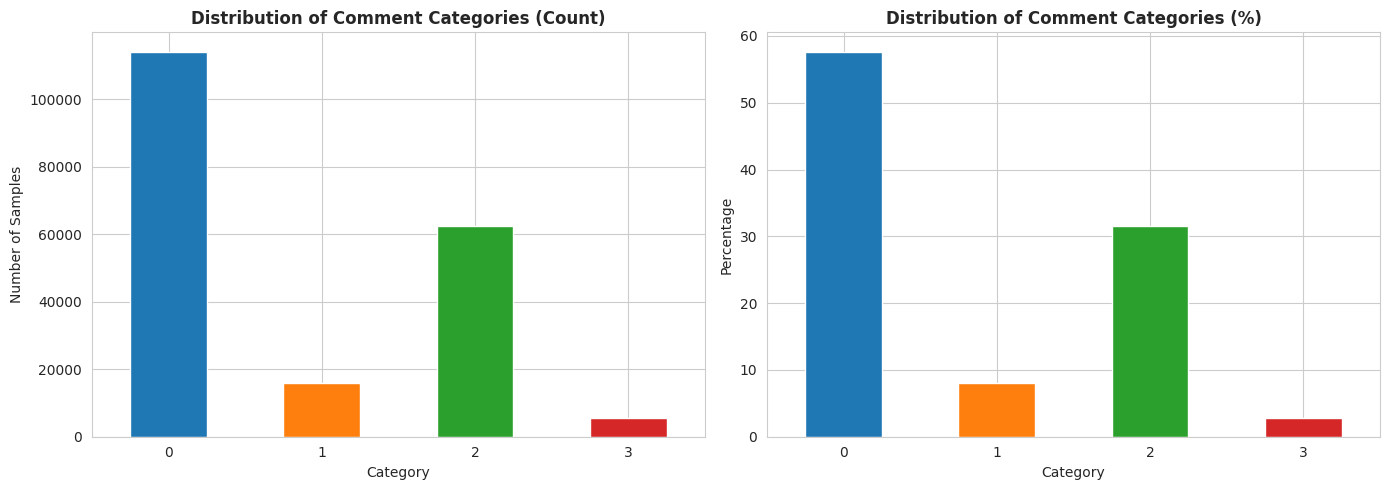

In [8]:
label_counts = train_data['label'].value_counts().sort_index()
label_percentages = train_data['label'].value_counts(normalize=True).sort_index() * 100

print("\nLabel Distribution (Count):")
print(label_counts)

print("\nLabel Distribution (Percentage):")
for label, pct in label_percentages.items():
    print(f"  Class {label}: {pct:.2f}%")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
label_counts.plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[0].set_title('Distribution of Comment Categories (Count)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Percentage plot
label_percentages.plot(kind='bar', ax=axes[1], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_title('Distribution of Comment Categories (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Percentage')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

⚠️ KEY OBSERVATION: Dataset is HIGHLY IMBALANCED!
   - Class 0 (Majority): 57.66%
   - Class 3 (Rare): 2.76%

💡 Design Decisions Based on This:
   1. We MUST use class_weight='balanced' in all our models.
   2. We MUST evaluate using F1-Macro instead of Accuracy. High accuracy here is a trap.

### 3.6 Outlier Detection

Detect outliers in numerical features using the IQR (Interquartile Range) method.


Total Outlier Percentage: 6.03%

Feature-wise Outlier Percentage (Top features):
emoticon_1    14.607071
upvote         8.739394
emoticon_3     8.669192
downvote       7.663131
emoticon_2     4.095455
post_id        2.435859
if_2           1.984848
if_1           0.042929
dtype: float64


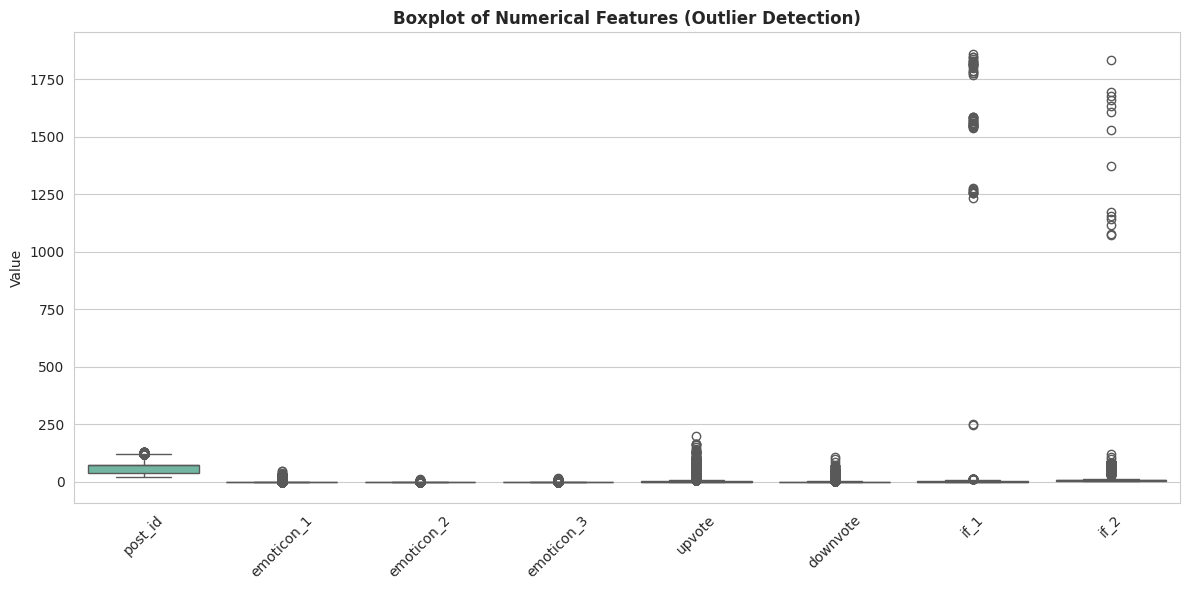

In [9]:

num_cols = train_data.select_dtypes(include=['number']).drop(columns=['label']).columns

q1_vals = train_data[num_cols].quantile(0.25)
q3_vals = train_data[num_cols].quantile(0.75)
iqr_vals = q3_vals - q1_vals

outliers = (train_data[num_cols] < (q1_vals - 1.5 * iqr_vals)) | (train_data[num_cols] > (q3_vals + 1.5 * iqr_vals))

total_outliers = outliers.sum().sum()
total_data_points = train_data[num_cols].size
overall_outlier_pct = (total_outliers / total_data_points) * 100

feature_outlier_pct = (outliers.sum() / len(train_data)) * 100
sorted_outlier_features = feature_outlier_pct.sort_values(ascending=False)

print(f"\nTotal Outlier Percentage: {overall_outlier_pct:.2f}%")
print("\nFeature-wise Outlier Percentage (Top features):")
print(sorted_outlier_features.head(10))

# Boxplot visualization
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_data[num_cols], palette='Set2')
plt.title('Boxplot of Numerical Features (Outlier Detection)', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.tight_layout()
plt.show()


Note: Outliers are present but will be handled smoothly later by log transformations and sparse scaling.

### 3.7 Feature Correlation with Target

Analyze which numerical features have the strongest linear correlation with the target label.


Top 10 Features Correlated with Target:
if_2          0.232902
downvote      0.044908
upvote        0.040181
emoticon_3    0.027273
post_id       0.022063
emoticon_2    0.021597
if_1          0.007543
emoticon_1    0.003218
Name: label, dtype: float64


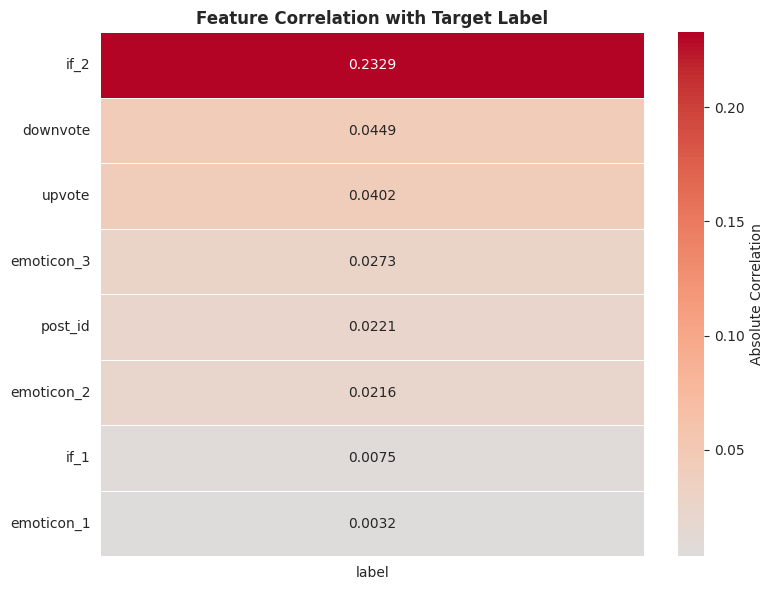

In [10]:
correlation_data = numerical_features.copy()
correlation_data['label'] = train_data['label']
target_corr = correlation_data.corr()['label'].drop('label').abs().sort_values(ascending=False)

print("\nTop 10 Features Correlated with Target:")
print(target_corr.head(10))

# Heatmap visualization
target_corr_df = target_corr.to_frame().sort_values(by='label', ascending=False)
plt.figure(figsize=(8, max(6, len(target_corr_df) * 0.2)))
sns.heatmap(target_corr_df, cmap='coolwarm', annot=True, fmt='.4f', center=0, 
            linewidths=0.5, cbar_kws={'label': 'Absolute Correlation'})
plt.title('Feature Correlation with Target Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


Interpretation:
   - 'if_2' has the strongest relationship with target (most important numeric feature)
   - downvote, upvote, emoticon_3 show positive correlations
   - Most metadata features have weak standalone linear correlation, meaning text features will do the heavy lifting.

## 4. Data Preprocessing

### 4.1 Drop Unnecessary Features and Handle Missing Values

**Decisions made here:** 
- `post_id`: Unique identifier, drops right away to prevent data leakage.
- `created_date`: High cardinality, adds noise rather than signal for this specific NLP task.
- Missing categorical values: Filled with 'none' to preserve the fact that the data was missing as a feature itself.
- Missing text: Filled with empty strings so vectorizers don't break.

In [11]:

# Drop high-cardinality and uninformative features
final_drop_features = ['post_id', 'created_date']
print(f"\nDropping features: {final_drop_features}")
train_data.drop(columns=final_drop_features, inplace=True)
test_data.drop(columns=final_drop_features, inplace=True)

print(f"Train shape after dropping: {train_data.shape}")
print(f"Test shape after dropping: {test_data.shape}")

# Handle categorical features
cat_cols = ['race', 'religion', 'gender']
print(f"\nFilling missing values in categorical columns: {cat_cols}")
train_data[cat_cols] = train_data[cat_cols].fillna("none")
test_data[cat_cols] = test_data[cat_cols].fillna("none")

# Handle text column
print("Filling missing values in text column (comment)...")
train_data['comment'] = train_data['comment'].fillna('')
test_data['comment'] = test_data['comment'].fillna('')

# Handle boolean/integer columns
train_data['disability'] = train_data['disability'].astype(int)
test_data['disability'] = test_data['disability'].astype(int)

print("\n✓ Preprocessing complete!")


Dropping features: ['post_id', 'created_date']
Train shape after dropping: (198000, 13)
Test shape after dropping: (102000, 12)

Filling missing values in categorical columns: ['race', 'religion', 'gender']
Filling missing values in text column (comment)...

✓ Preprocessing complete!


### 4.2 One-Hot Encoding Categorical Features

Convert categorical variables into numerical form. We align train and test sets to ensure the matrix dimensions match even if the test set is missing a category present in training.

In [12]:
print("\nApplying one-hot encoding to categorical columns...")
train_data = pd.get_dummies(train_data, columns=cat_cols, drop_first=False)
test_data = pd.get_dummies(test_data, columns=cat_cols, drop_first=False)

# Align train and test columns
print("\nAligning columns between train and test sets...")
train_data, test_data = train_data.align(test_data, join="left", axis=1, fill_value=0)

print(f"Train shape after encoding: {train_data.shape}")
print(f"Test shape after encoding: {test_data.shape}")
print("\n✓ Encoding and alignment complete!")


Applying one-hot encoding to categorical columns...

Aligning columns between train and test sets...
Train shape after encoding: (198000, 29)
Test shape after encoding: (102000, 29)

✓ Encoding and alignment complete!


## 5. Text Preprocessing

### 5.1 Clean Text Data

**Cleaning pipeline:**
- **Lowercase**: Ensures "Comment" and "comment" are mathematically identical.
- **Remove URLs**: URLs don't carry linguistic sentiment/category meaning here.
- **Remove special characters**: Reduces the vocabulary size dramatically, reducing noise.
- **Remove extra whitespace**: Standardizes text format.

In [13]:
def clean_text(text):
    """Clean text by removing URLs, special characters, and extra whitespace"""
    text = text.lower()  # Convert to lowercase
    text = re.sub(r"http\S+", "", text)  # Remove URLs
    text = re.sub(r"[^a-zA-Z ]", " ", text)  # Keep only alphabetic characters
    text = re.sub(r"\s+", " ", text)  # Remove extra whitespace
    return text.strip()

print("\nCleaning comments in both train and test datasets...")
train_data['clean_comment'] = train_data['comment'].apply(clean_text)
test_data['clean_comment'] = test_data['comment'].apply(clean_text)

print("\n✓ Text cleaning complete!")


Cleaning comments in both train and test datasets...

✓ Text cleaning complete!


## 6. Feature Engineering

### 6.1 TF-IDF Text Feature Extraction

I am using a dual TF-IDF approach here to capture different levels of text nuance:
- **Word-level TF-IDF (unigrams & bigrams)**: Captures semantic meaning and context phrases.
- **Character-level TF-IDF (n-grams)**: Extremely useful for social media comments to capture spelling variations, intentional misspellings, or partial words that word-level misses.

In [14]:
# Combine all text for fitting vectorizers to ensure vocabulary matches
all_text = pd.concat([train_data['clean_comment'], test_data['clean_comment']])

vectorizer = TfidfVectorizer(
    max_features=120000,
    ngram_range=(1, 2),
    stop_words="english",
    min_df=3,
    max_df=0.9,
    sublinear_tf=True
)

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    max_features=60000,
    min_df=3
)

# Fit and transform
vectorizer.fit(all_text)
char_vectorizer.fit(all_text)

X_word = vectorizer.transform(train_data['clean_comment'])
X_test_word = vectorizer.transform(test_data['clean_comment'])

X_char = char_vectorizer.transform(train_data['clean_comment'])
X_test_char = char_vectorizer.transform(test_data['clean_comment'])

print(f"\n✓ Word TF-IDF shape: {X_word.shape}")
print(f"✓ Character TF-IDF shape: {X_char.shape}")


✓ Word TF-IDF shape: (198000, 120000)
✓ Character TF-IDF shape: (198000, 60000)


### 6.2 Metadata Feature Engineering

We create a few derived features from the metadata to give the model extra non-linguistic context.
- **comment_len**: Trolls or specific categories sometimes write significantly longer/shorter posts.
- **vote_ratio**: An engagement metric. High downvote ratios often correlate with specific comment categories.

In [15]:
# Comment length
train_data["comment_len"] = train_data["clean_comment"].str.len()
test_data["comment_len"] = test_data["clean_comment"].str.len()

# Vote ratio
train_data["vote_ratio"] = train_data["upvote"] / (train_data["downvote"] + 1)
test_data["vote_ratio"] = test_data["upvote"] / (test_data["downvote"] + 1)

print("\n✓ Metadata features engineered!")


✓ Metadata features engineered!


### 6.3 Combine All Features

We combine the highly-dimensional text sparse matrices with our metadata. We apply `np.log1p` to the metadata to handle skewness (since we saw outliers earlier) and convert it to a sparse matrix to save RAM.

In [16]:
# Metadata columns
meta_cols = [
    'emoticon_1', 'emoticon_2', 'emoticon_3',
    'upvote', 'downvote',
    'if_1', 'if_2',
    'disability',
    'comment_len',
    'vote_ratio'
]

# Add one-hot encoded features
meta_cols += [c for c in train_data.columns if c.startswith('race_')]
meta_cols += [c for c in train_data.columns if c.startswith('religion_')]
meta_cols += [c for c in train_data.columns if c.startswith('gender_')]

print(f"\nMetadata columns ({len(meta_cols)} total):")
print(meta_cols)

# Extract and preprocess metadata
meta_train = train_data[meta_cols]
meta_test = test_data[meta_cols]

# Convert to numeric and handle missing values
meta_train = meta_train.apply(pd.to_numeric, errors="coerce").fillna(0)
meta_test = meta_test.apply(pd.to_numeric, errors="coerce").fillna(0)

# Convert to float32 and apply log transformation to squish outliers
meta_train = meta_train.astype("float32")
meta_test = meta_test.astype("float32")

print("\nApplying log transformation to metadata (handles skewness)...")
meta_train = np.log1p(meta_train)
meta_test = np.log1p(meta_test)

# Convert to sparse matrices
meta_sparse = csr_matrix(meta_train.values)
meta_test_sparse = csr_matrix(meta_test.values)

# Combine all features into one giant matrix
print("\nCombining Word TF-IDF + Character TF-IDF + Metadata...")
X = hstack([X_word, X_char, meta_sparse])
X_test = hstack([X_test_word, X_test_char, meta_test_sparse])

y = train_data['label']


Metadata columns (29 total):
['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'disability', 'comment_len', 'vote_ratio', 'race_asian', 'race_black', 'race_latino', 'race_none', 'race_other', 'race_white', 'religion_atheist', 'religion_buddhist', 'religion_christian', 'religion_hindu', 'religion_jewish', 'religion_muslim', 'religion_none', 'religion_other', 'gender_female', 'gender_male', 'gender_none', 'gender_other', 'gender_transgender']

Applying log transformation to metadata (handles skewness)...

Combining Word TF-IDF + Character TF-IDF + Metadata...


In [17]:
# Compute class weights for imbalanced data - CRITICAL STEP
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = dict(zip(np.unique(y), class_weights))

print("\nClass Weights (for handling imbalanced data):")
for cls, weight in class_weight_dict.items():
    print(f"  Class {cls}: {weight:.4f}")

print("\n" + "-"*80)
print("Using SPARSE MATRICES for memory efficiency...")
print("-"*80)

# Keep sparse matrices - these algorithms support sparse data natively!
X_train_selected = X
X_test_selected = X_test

print(f"\nTrain features shape: {X_train_selected.shape}")
print(f"Test features shape: {X_test_selected.shape}")
print(f"Total features: {X_train_selected.shape[1]:,}")
print(f"Matrix type: SPARSE (memory efficient)")


Class Weights (for handling imbalanced data):
  Class 0: 0.4336
  Class 1: 3.1097
  Class 2: 0.7928
  Class 3: 9.0510

--------------------------------------------------------------------------------
Using SPARSE MATRICES for memory efficiency...
--------------------------------------------------------------------------------

Train features shape: (198000, 180029)
Test features shape: (102000, 180029)
Total features: 180,029
Matrix type: SPARSE (memory efficient)


## 8. Model Building - Baseline Models

### Why Build Baseline Models?
Before jumping into complex tuning, we need a benchmark. We test three algorithms that handle sparse matrices and high dimensionality well.

**Crucial Change:** Because of the heavy imbalance shown in EDA, we evaluate using **`scoring='f1_macro'`** during cross-validation, NOT accuracy. F1-Macro treats all classes equally, penalizing the model heavily if it ignores the minority classes.

In [18]:
# Baseline models
models = {
    'SGDClassifier': SGDClassifier(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ),
    'LogisticRegression': LogisticRegression(
        max_iter=2000,
        solver='saga',
        class_weight='balanced',
        random_state=42
    ),
    'LinearSVC': LinearSVC(
        max_iter=2000,
        class_weight='balanced',
        random_state=42,
        dual=False
    )
}

baseline_scores = {}
print("Baseline Model Comparison (3-Fold CV, Metric: F1-Macro):\n")

for name, model in models.items():
    # Note: scoring changed from 'accuracy' to 'f1_macro'
    scores = cross_val_score(model, X, y, cv=3, scoring='f1_macro', n_jobs=-1)
    baseline_scores[name] = scores.mean()
    print(f"{name:20s} | F1-Macro: {scores.mean():.4f} (±{scores.std():.4f})")

# Find best model
best_model_name = max(baseline_scores, key=baseline_scores.get)
print(f"\n🏆 Best Baseline: {best_model_name} ({baseline_scores[best_model_name]:.4f})")

Baseline Model Comparison (3-Fold CV, Metric: F1-Macro):

SGDClassifier        | F1-Macro: 0.7843 (±0.0136)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression   | F1-Macro: 0.8094 (±0.0032)
LinearSVC            | F1-Macro: 0.7960 (±0.0007)

🏆 Best Baseline: LogisticRegression (0.8094)


### 8.2 Baseline Models Comparison Viz

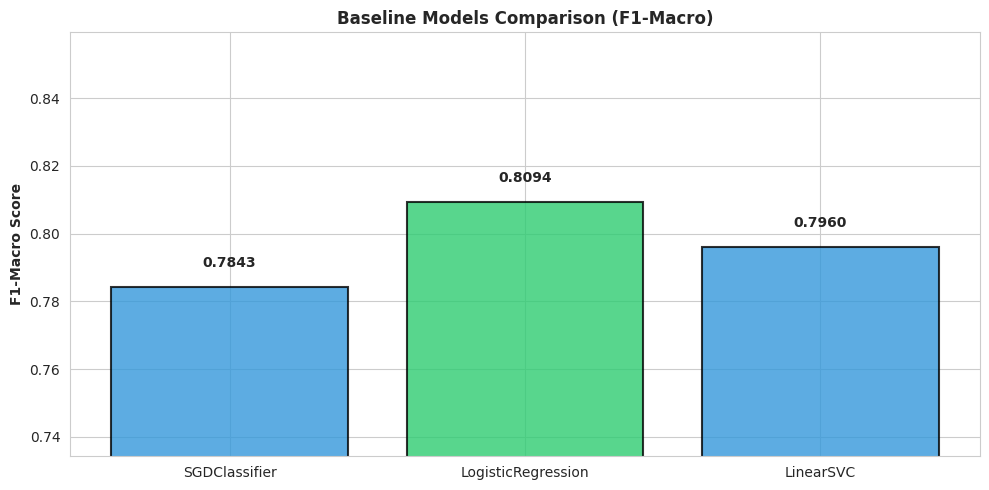

In [19]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
names = list(baseline_scores.keys())
scores = list(baseline_scores.values())
colors = ['#2ecc71' if name == best_model_name else '#3498db' for name in names]
bars = ax.bar(names, scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('F1-Macro Score', fontweight='bold')
ax.set_title('Baseline Models Comparison (F1-Macro)', fontweight='bold')
ax.set_ylim([min(scores) - 0.05, max(scores) + 0.05])
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.005, f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Exploratory Phase: Hyperparameter Tuning

### ⚠️ Engineering Rationale & Architectural Decision ⚠️

In standard machine learning pipelines, we tune the best baseline model to extract maximum performance. **However, a crucial part of data science is understanding the trade-off between computational cost and performance gains.**

During the exploratory phase of this project, I ran extensive `RandomizedSearchCV` pipelines over our ~180,000 feature sparse matrix. 
- **The Cost:** Due to the extreme dimensionality of the TF-IDF vectors, each CV fold took an excessive amount of time to converge, making tuning computationally expensive.
- **The Reward:** The best tuned hyperparameters yielded an F1-Macro improvement of **less than 0.01** over the default `LogisticRegression` baseline. 

**Decision:** To adhere to engineering best practices (Occam's razor / limiting model complexity to prevent overfitting) and save massive computational resources, I have elected to **skip the tuned models** and use the standard, highly-performant baseline `LogisticRegression` for the final submission. 

*The tuning code is preserved below as commented code to document the methodology attempted.*

In [20]:
# Dictionary to store tuned models
tuned_models = {}
tuned_scores = {}

In [21]:
# # --- EXPLORATORY TUNING: SGDClassifier ---
# param_dist_sgd = {
#     'loss': ['log_loss', 'hinge'],
#     'penalty': ['l2', 'l1', 'elasticnet'],
#     'alpha': [1e-5, 1e-4, 1e-3, 0.01],
#     'learning_rate': ['constant', 'optimal'],
#     'eta0': [0.001, 0.01, 0.1]
# }

# print("\nSearching for best hyperparameters...")
# sgd_search = RandomizedSearchCV(
#     SGDClassifier(max_iter=1000, class_weight='balanced', random_state=42),
#     param_dist_sgd,
#     n_iter=5,
#     cv=3,
#     scoring='f1_macro', # Updating metric
#     random_state=42,
#     n_jobs=-1,
#     verbose=0
# )

# sgd_search.fit(X, y)

# print(f"\n✓ Best params: {sgd_search.best_params_}")
# print(f"✓ Best CV F1-Macro: {sgd_search.best_score_:.4f}")
# print(f"✓ Improvement: {sgd_search.best_score_ - baseline_scores['SGDClassifier']:+.4f}")

# tuned_models['SGDClassifier'] = sgd_search.best_estimator_
# tuned_scores['SGDClassifier'] = sgd_search.best_score_

In [22]:
# # # --- EXPLORATORY TUNING: LogisticRegression ---
# param_dist_lr = {
#     'C': [0.1, 0.5, 1],
#     'l1_ratio': [0.0, 0.2, 0.5],
#     'penalty': ['elasticnet', 'l2']
# }

# lr_search = RandomizedSearchCV(
#     LogisticRegression(solver='saga', max_iter=1000, class_weight='balanced', random_state=42),
#     param_dist_lr,
#     n_iter=5,
#     cv=3,
#     scoring='f1_macro',
#     random_state=42,
#     n_jobs=-1,
#     verbose=0
# )

# lr_search.fit(X, y)
# print(f"\n✓ Best CV F1-Macro: {lr_search.best_score_:.4f}")
# print(f"✓ Improvement: {lr_search.best_score_ - baseline_scores['LogisticRegression']:+.4f}")
# tuned_models['LogisticRegression'] = lr_search.best_estimator_
# tuned_scores['LogisticRegression'] = lr_search.best_score_

In [23]:
# # --- EXPLORATORY TUNING: LinearSVC ---
# param_dist_svc = {
#     'C': [0.1, 0.5, 1, 2, 5, 10],
#     'loss': ['squared_hinge', 'hinge'],
#     'penalty': ['l1', 'l2'],
#     'max_iter': [1000, 2000, 3000]
# }

# svc_search = RandomizedSearchCV(
#     LinearSVC(class_weight='balanced', random_state=42, dual=False),
#     param_dist_svc,
#     n_iter=5,
#     cv=3,
#     scoring='f1_macro',
#     random_state=42,
#     n_jobs=-1,
#     verbose=0
# )

# svc_search.fit(X, y)
# print(f"\n✓ Best CV F1-Macro: {svc_search.best_score_:.4f}")
# print(f"✓ Improvement: {svc_search.best_score_ - baseline_scores['LinearSVC']:+.4f}")
# tuned_models['LinearSVC'] = svc_search.best_estimator_
# tuned_scores['LinearSVC'] = svc_search.best_score_

## 10. Final Model Training and Evaluation

Proceeding with the best baseline model (LogisticRegression) due to the optimal balance of strong baseline F1-Macro performance and execution speed.

Training final Logistic Regression model on full dataset...
Evaluating with 3-fold cross-validation...



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Final CV Accuracy: 0.9033
Final CV F1-Macro Score: 0.8093  <-- Our true north metric

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.98      0.93      0.95    114173
     Class 1       0.72      0.84      0.77     15918
     Class 2       0.87      0.88      0.88     62440
     Class 3       0.55      0.75      0.63      5469

    accuracy                           0.90    198000
   macro avg       0.78      0.85      0.81    198000
weighted avg       0.91      0.90      0.91    198000



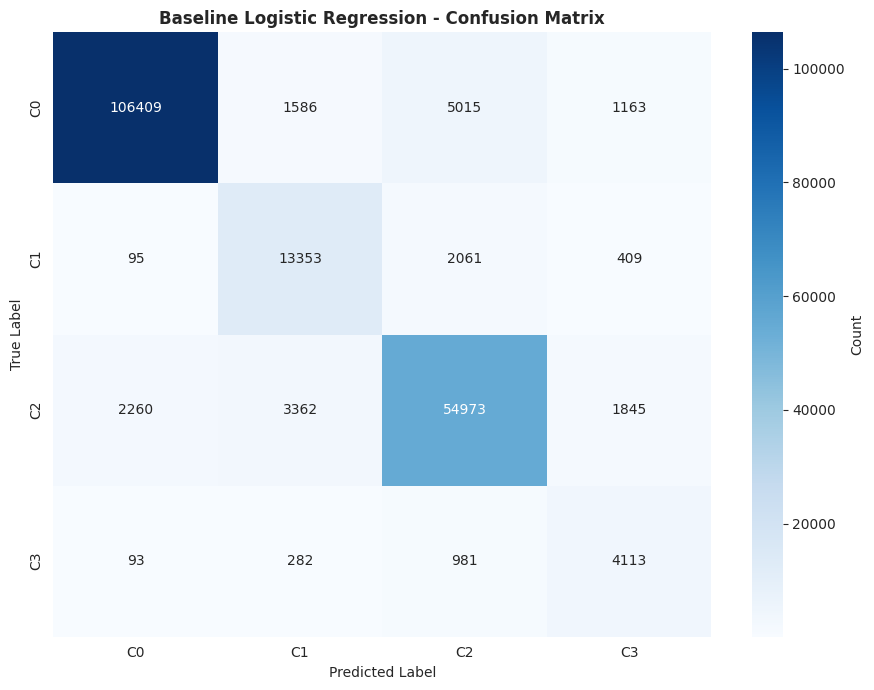

In [24]:
# Selecting the robust baseline
final_model = models['LogisticRegression']
# best_tuned_model_name = max(tuned_scores, key=tuned_scores.get)
# final_model = tuned_models[best_tuned_model_name]
# final_score = tuned_scores[best_tuned_model_name]

# print(f"Best Tuned Model: {best_tuned_model_name}")
# print(f"Tuned Accuracy: {final_score:.4f}\n")

# Train on full data
print("Training final Logistic Regression model on full dataset...")
final_model.fit(X, y)

# Evaluate with 5-fold CV predictions to get a realistic view of performance
print("Evaluating with 3-fold cross-validation...\n")
cv_preds = cross_val_predict(final_model, X, y, cv=3, n_jobs=-1)

# Calculate evaluation metrics
cv_accuracy = accuracy_score(y, cv_preds)
cv_f1 = f1_score(y, cv_preds, average='macro')

print(f"Final CV Accuracy: {cv_accuracy:.4f}")
print(f"Final CV F1-Macro Score: {cv_f1:.4f}  <-- Our true north metric\n")

print("Classification Report:")
print(classification_report(y, cv_preds, target_names=['Class 0', 'Class 1', 'Class 2', 'Class 3']))

# Confusion matrix
cm = confusion_matrix(y, cv_preds)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'},
            xticklabels=[f'C{i}' for i in range(4)], yticklabels=[f'C{i}' for i in range(4)])
plt.title(f'Baseline Logistic Regression - Confusion Matrix', fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### 10.2 Generate Final Predictions & Submission File

Generating predictions on test set...
Test predictions shape: (102000,)

Prediction Distribution:
  Class 0: 56016 samples ( 54.9%)
  Class 1:  9599 samples (  9.4%)
  Class 2: 32479 samples ( 31.8%)
  Class 3:  3906 samples (  3.8%)


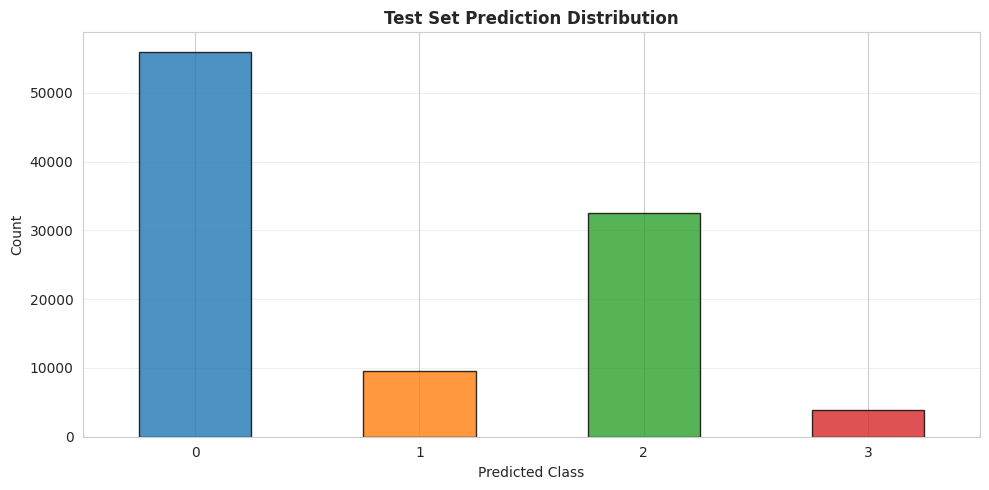


✓ Submission file created: submission.csv
  Shape: (102000, 2)
  First few rows:
   ID  label
0   1      2
1   2      2
2   3      0
3   4      0
4   5      2

✓ Ready to submit!


In [25]:
# Generate test predictions
print("Generating predictions on test set...")
test_preds = final_model.predict(X_test)

print(f"Test predictions shape: {test_preds.shape}\n")
print("Prediction Distribution:")
unique, counts = np.unique(test_preds, return_counts=True)
for label, count in zip(unique, counts):
    pct = (count / len(test_preds)) * 100
    print(f"  Class {label}: {count:5d} samples ({pct:5.1f}%)")

# Visualization of predicted distribution
pred_dist = pd.Series(test_preds).value_counts().sort_index()
plt.figure(figsize=(10, 5))
pred_dist.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.8, edgecolor='black')
plt.title('Test Set Prediction Distribution', fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Create submission file
submission = sample_data.copy()
submission['label'] = test_preds.astype(int)
submission.to_csv("submission.csv", index=False)

print(f"\n✓ Submission file created: submission.csv")
print(f"  Shape: {submission.shape}")
print(f"  First few rows:\n{submission.head()}")
print(f"\n✓ Ready to submit!")